In [ ]:
# ==========================================
# TESIS ZMVM: PM, clima y salud
# Autor: Arely Leal
# Descripción: Script en Python para generar grafico de las concentraciones diarias por año para material particulado. 
# FUNCIONA PARA PM10 (2000-2019) Y PM2.5 (2003-2019)
# ==========================================


['FECHA', 'PROMEDIO_GENERAL']


,FECHA,PROMEDIO_GENERAL
0,2000-01-01,97.0
1,2000-01-02,55.0
2,2000-01-03,52.0
3,2000-01-04,58.0
4,2000-01-05,69.0


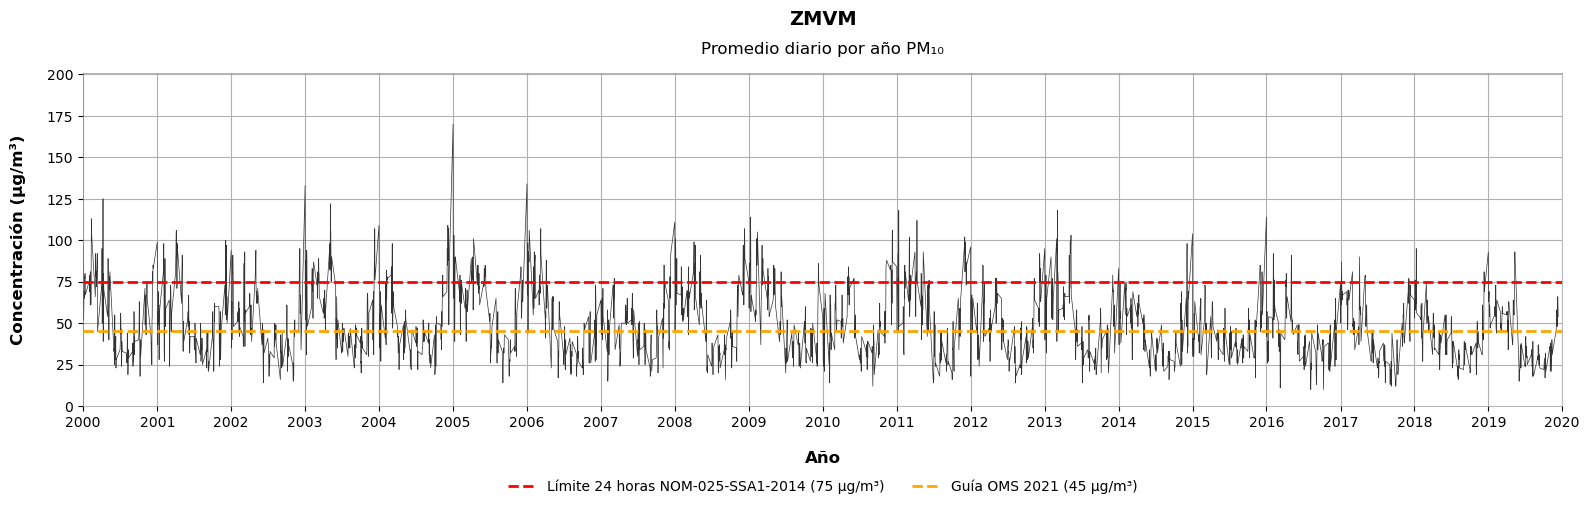

Gráfico guardado en: /Users/arelyleal/Downloads/GUARDAR_GRAFICOS/ZMVM.png


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os

# Leer archivo 
archivo_csv = "AGREGAR RUTA DEL ARCHIVO (RR)"
ruta_salida = "AGREGAR RUTA DEL SALIDA"
os.makedirs(ruta_salida, exist_ok=True)
df = pd.read_csv(archivo_csv)
df.columns = df.columns.str.strip()
df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True, errors="coerce")
print(df.columns.tolist())
display(df.head())
#print(df["FECHA"].head(10)) FORMATO DE FECHA

# Delegación a graficar
columna_valores = "PROMEDIO_GENERAL"        # nombre exacto de la delegación
nombre_estacion = "ZMVM"       # usado para título y nombre del archivo

# PROCESAMIENTO
df[columna_valores] = pd.to_numeric(df[columna_valores], errors="coerce")
df_local = df[["FECHA", columna_valores]].copy()
df_local = df_local.sort_values("FECHA")
df_local["PICOS"] = df_local[columna_valores].apply(lambda x: x if x > 80 else np.nan)

# TÍTULOS
padding_titulo = 35
padding_subtitulo = df_local[columna_valores].max() * 1.25

# GRAFICAR
plt.figure(figsize=(16, 6))
plt.plot(df_local["FECHA"], df_local[columna_valores], color='#333333', linewidth=0.5, zorder=2)

#MODIFICAR EN FUNCION DE PM10 O PM2.5
plt.axhline(75, color='red', linestyle='--', linewidth=2,  label="Límite 24 horas NOM-025-SSA1-2014 (75 µg/m³)", zorder=3)


#PICOS
#plt.scatter(df_local["FECHA"], df_local["PICOS"], color="#B22222", label=">150 µg/m³", s=70, marker='x', linewidths=2.5, zorder=5)

#MODIFICAR EN FUNCION DE PM10 O PM2.5
plt.axhline(45, color='orange', linestyle='--', linewidth=2, label="Guía OMS 2021 (45 µg/m³)", zorder=3)

# FORMATO EJE X E Y
plt.xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2020-01-01"))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.ylim(0, df_local[columna_valores].max(skipna=True) * 1.18)

# ESTILO Y MARCO
#TITULO PARA ZMVM
#plt.title("ZMVM", fontsize=14, fontweight='bold', pad=padding_titulo, loc='center')

#TITULO PARA ESTACIONES
plt.title(nombre_estacion.upper(), fontsize=14, fontweight='bold', pad=padding_titulo, loc='center')
plt.text(pd.Timestamp("2010-01-01"), padding_subtitulo, "Promedio diario por año PM..", ha='center', fontsize=12)
plt.xlabel("Año", fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel("Concentración (µg/m³)", fontsize=12, fontweight='bold', labelpad=15)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.30), ncol=3, frameon=False)
plt.grid(True)

# Marco más tenue
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.4)
    spine.set_color('gray')

plt.tight_layout(rect=[0, 0, 1, 0.93])

# GUARDAR
nombre_archivo = f"{nombre_estacion.replace(' ', '_').upper()}.png"
ruta_completa = os.path.join(ruta_salida, nombre_archivo)
plt.savefig(ruta_completa, dpi=300)
plt.show()

print(f"Gráfico guardado en: {ruta_completa}")